### lets use Grad- Cam(tells us which thing our model focused on)

In [2]:
import torch
import torchvision
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision import models
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cuda


In [4]:
model = torchvision.models.resnet18(pretrained=True)
model = model.to(device)
model.eval()

C:\Users\Panshul\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Panshul\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # ResNet expects 224×224 images
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

In [6]:
img = Image.open("100.png").convert('RGB')
input_tensor = transform(img).unsqueeze(0).to(device)

In [7]:
activations = {}
gradients = {}

def forward_hook(module, input, output):
    activations['value'] = output

def backward_hook(module, grad_in, grad_out):
    gradients['value'] = grad_out[0]

In [8]:
target_layer = model.layer4[1].conv2
target_layer.register_forward_hook(forward_hook)
target_layer.register_backward_hook(backward_hook)

In [9]:
output = model(input_tensor)
pred_class = output.argmax(dim=1).item()

C:\Users\Panshul\AppData\Roaming\Python\Python313\site-packages\torch\nn\modules\module.py:1864: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


In [10]:
model.zero_grad()
score = output[0, pred_class]
score.backward()

In [12]:
act = activations['value'].detach()
grad = gradients['value'].detach()

weights = grad.mean(dim=[2, 3], keepdim=True)  
cam = (weights * act).sum(dim=1, keepdim=True)  
cam = F.relu(cam)                              

In [13]:
cam = cam - cam.min()
cam = cam / cam.max()
cam = cam.squeeze().cpu().numpy()

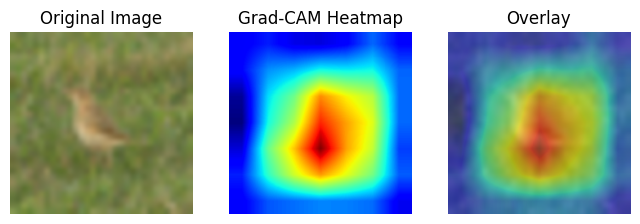

In [15]:
import cv2

img_np = np.array(img.resize((224, 224))) / 255.0
heatmap = cv2.resize(cam, (224, 224))  # resize CAM to image size

# Convert heatmap to RGB
heatmap = plt.cm.jet(heatmap)[..., :3]

# Overlay
overlay = 0.5 * img_np + 0.5 * heatmap
overlay = np.clip(overlay, 0, 1)

plt.figure(figsize=(8, 4))
plt.subplot(1, 3, 1)
plt.title("Original Image")
plt.imshow(img_np)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title("Grad-CAM Heatmap")
plt.imshow(heatmap)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title("Overlay")
plt.imshow(overlay)
plt.axis('off')
plt.show()